In [1]:
pip install accelerate>=1.1.0

Note: you may need to restart the kernel to use updated packages.


In [2]:
!pip install --upgrade transformers

In [3]:
!pip install transformers torch

In [4]:
!pip install nltk

In [5]:
import pandas as pd
import numpy as np
import re
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer 

import nltk
nltk.download('stopwords')
nltk.download('wordnet')

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV

from transformers import pipeline

[nltk_data] Downloading package stopwords to C:\Users\Sahil
[nltk_data]     Sawant\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Sahil
[nltk_data]     Sawant\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [6]:
data = pd.read_csv('data/NLP/IMDB Dataset.csv')

In [7]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [8]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [9]:
data.isnull().sum()

review       0
sentiment    0
dtype: int64

In [10]:
data.duplicated()

0        False
1        False
2        False
3        False
4        False
         ...  
49995    False
49996    False
49997    False
49998    False
49999    False
Length: 50000, dtype: bool

In [11]:
data['sentiment'].unique()

array(['positive', 'negative'], dtype=object)

In [12]:
#Converting labels to numbers
data['sentiment'] = data['sentiment'].map({'positive':1,"negative":0})

In [13]:
data.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,1
1,A wonderful little production. <br /><br />The...,1
2,I thought this was a wonderful way to spend ti...,1
3,Basically there's a family where a little boy ...,0
4,"Petter Mattei's ""Love in the Time of Money"" is...",1


In [14]:
data['sentiment'].value_counts()

sentiment
1    25000
0    25000
Name: count, dtype: int64

In [15]:
#Custom function to clean data
def clean_text(text):
    #lower case text
    text = text.lower()
    #Remove html tags
    text = re.sub(r"<.*?>","",text)
    text = re.sub(r"[^a-zA-Z]", " ",text)
    # Remove Numbers
    text = re.sub(r"\d+", " ", text)
    #Remove Extra spaces
    text = re.sub(r"\s+", " ", text)
    return text

In [16]:
#aplying cleaning function to review
data['review'] = data['review'].apply(clean_text)

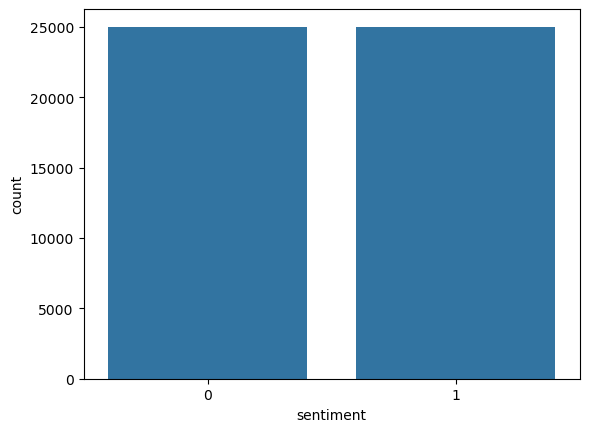

In [17]:
# Visualizing sentiment analysis
sns.countplot(x="sentiment",data = data)
plt.show()

In [18]:
# removing stop words from the text

stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

data["review"] = data['review'].apply(remove_stopwords)

In [19]:
data['review'][0]

'one reviewers mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scenes violence set right word go trust show faint hearted timid show pulls punches regards drugs sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focuses mainly emerald city experimental section prison cells glass fronts face inwards privacy high agenda em city home many aryans muslims gangstas latinos christians italians irish scuffles death stares dodgy dealings shady agreements never far away would say main appeal show due fact goes shows dare forget pretty pictures painted mainstream audiences forget charm forget romance oz mess around first episode ever saw struck nasty surreal say ready watched developed taste oz got accustomed high levels graphic violence violence injustice crooked guards sold nickel inmates kill order get away well mannered middle class inmates turned prison bitches due lack street skill

In [20]:
#Lemmtizing text in the review
lemmatizer = WordNetLemmatizer()

def lemmatize(text):
    words = text.split()
    words = [lemmatizer.lemmatize(w) for w in words]
    return " ".join(words)

data["review"] = data["review"].apply(lemmatize)

In [21]:
data['review'][0]

'one reviewer mentioned watching oz episode hooked right exactly happened first thing struck oz brutality unflinching scene violence set right word go trust show faint hearted timid show pull punch regard drug sex violence hardcore classic use word called oz nickname given oswald maximum security state penitentary focus mainly emerald city experimental section prison cell glass front face inwards privacy high agenda em city home many aryan muslim gangsta latino christian italian irish scuffle death stare dodgy dealing shady agreement never far away would say main appeal show due fact go show dare forget pretty picture painted mainstream audience forget charm forget romance oz mess around first episode ever saw struck nasty surreal say ready watched developed taste oz got accustomed high level graphic violence violence injustice crooked guard sold nickel inmate kill order get away well mannered middle class inmate turned prison bitch due lack street skill prison experience watching oz m

In [22]:
#splitting data for testing and validation

x = data['review']
y = data['sentiment']

x_train,x_test,y_train,y_test = train_test_split(x,y, test_size = 0.2,random_state= 42)

In [23]:
# Using Tfidf to conver words into numerical vectors

vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1,2), 
    min_df=5             
)

x_train_tfidf = vectorizer.fit_transform(x_train)
x_test_tfidf = vectorizer.transform(x_test)

In [24]:
# using logistic regression, naive bayes and  random forest to train model
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Naive Bayes": MultinomialNB(),
    "SVM": LinearSVC()
}

In [25]:
# training and evaluatin_g model performance
results = {}

for name, model in models.items():
        model.fit(x_train_tfidf, y_train)
        
        predictions = model.predict(x_test_tfidf)
        
        accuracy = accuracy_score(y_test, predictions)
        
        results[name] = accuracy
        
        print("\n", name)
        print("Accuracy:", accuracy)
        print(classification_report(y_test, predictions))


 Logistic Regression
Accuracy: 0.8912
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000


 Naive Bayes
Accuracy: 0.8586
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      4961
           1       0.85      0.87      0.86      5039

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000


 SVM
Accuracy: 0.8834
              precision    recall  f1-score   support

           0       0.89      0.87      0.88      4961
           1       0.88      0.89      0.89      5039

    accuracy                           0.88     10000
   macro avg       0.88      0.88  

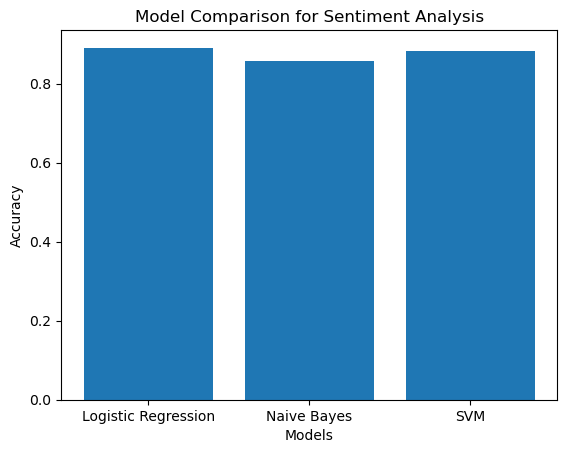

In [26]:
#visualizing model prediction
import matplotlib.pyplot as plt

models_names = list(results.keys())
scores = list(results.values())

plt.bar(models_names, scores)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison for Sentiment Analysis")
plt.show()

In [27]:
#Using GridsearchCV() hyperarameter tuning
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'penalty': ['l2'],
    'solver': ['liblinear', 'lbfgs']
}


In [28]:
#Creating gridsearchcv model

grid = GridSearchCV(
    LogisticRegression(max_iter=1000),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

In [29]:
grid.fit(x_train_tfidf,y_train)
print("Best Parameters:", grid.best_params_)


Best Parameters: {'C': 1, 'penalty': 'l2', 'solver': 'liblinear'}


In [30]:
#Evaluating the tuned model
best_model = grid.best_estimator_

predictions = best_model.predict(x_test_tfidf)

accuracy = accuracy_score(y_test, predictions)

print("Tuned Accuracy:", accuracy)
print(classification_report(y_test, predictions))

Tuned Accuracy: 0.8915
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4961
           1       0.88      0.90      0.89      5039

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [31]:
#Creating an custom function to check model answer
def predict_sentiment(text):

    #Convert text to vector
    text_vector = vectorizer.transform([text])

    #predict sentiment
    prediction = best_model.predict(text_vector)[0]

    if prediction == 1:
        return "Positive Review"
    else:
        return "Negativve Review"

In [32]:
review = "Movie is can be improved"

print(predict_sentiment(review))

Positive Review


Model and vectorizer saved successfully!


In [34]:
#Using LSTM deep learning model 
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding,LSTM,Dense
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [35]:
# Using tokenisation

tokenizer = Tokenizer(num_words=5000)
tokenizer.fit_on_texts(x_train)

x_train_seq = tokenizer.texts_to_sequences(x_train)
x_test_seq = tokenizer.texts_to_sequences(x_test)

x_train_pad = pad_sequences(x_train_seq, maxlen=200)
x_test_pad = pad_sequences(x_test_seq, maxlen=200)

In [36]:
#Building LSTM model
lstm_model = Sequential([
    Embedding(input_dim=5000,output_dim=128),
    LSTM(64),
    Dense(1,activation='sigmoid')
])

In [37]:
#Compiling and training lstm
lstm_model.compile(optimizer='adam', loss = 'binary_crossentropy', metrics = ['accuracy'])
lstm_model.fit(x_train_pad,y_train,epochs=2,batch_size=32)

Epoch 1/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 113s 86ms/step - accuracy: 0.8513 - loss: 0.3458
Epoch 2/2
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 105s 84ms/step - accuracy: 0.9019 - loss: 0.2493


In [38]:
# Evaluate LSTM

lstm_loss, lstm_acc = lstm_model.evaluate(x_test_pad, y_test)
print("LSTM Accuracy:", lstm_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 40ms/step - accuracy: 0.8774 - loss: 0.2920
LSTM Accuracy: 0.8773999810218811


In [40]:
#using hugging face pre-trained models for transformers
from transformers import pipeline

hf_model = pipeline(
    "sentiment-analysis",
    model="distilbert-base-uncased-finetuned-sst-2-english"
)

config.json:   0%|          | 0.00/629 [00:00<?, ?B/s]

C:\Users\Sahil Sawant\anaconda3\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\Sahil Sawant\.cache\huggingface\hub\models--distilbert-base-uncased-finetuned-sst-2-english. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

In [44]:
hf_model("This movie was not bad")

[{'label': 'POSITIVE', 'score': 0.9990652203559875}]

In [45]:
#Custom function to predict output
def predict_hf(text):
    result = hf_model(text)[0]
    return result['label'], result['score']

In [50]:
print(predict_hf("This movie story was amazing "))
print(predict_hf("Worst movie ever"))

('POSITIVE', 0.9998801946640015)
('NEGATIVE', 0.9997616410255432)


In [51]:
#Comparision between models
sample_text = "This movie was not good"

# ML model
print("ML Model:", predict_sentiment(sample_text))

# LSTM model
seq = tokenizer.texts_to_sequences([sample_text])
pad = pad_sequences(seq, maxlen=200)
lstm_pred = lstm_model.predict(pad)[0][0]
print("LSTM:", "Positive" if lstm_pred > 0.5 else "Negative")

# HuggingFace model
print("HF Transformer:", predict_hf(sample_text))

ML Model: Positive Review
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 544ms/step
LSTM: Positive
HF Transformer: ('NEGATIVE', 0.9997819066047668)


In [52]:
#saving the tuned model
import pickle

# path to backend folder
model_path = r"F:\Sahil\SentimentAnalysis\backend\model.pkl"
vectorizer_path = r"F:\Sahil\SentimentAnalysis\backend\vectorizer.pkl"

# save model
with open(model_path, "wb") as f:
    pickle.dump(best_model, f)

# save vectorizer
with open(vectorizer_path, "wb") as f:
    pickle.dump(vectorizer, f)

# Save LSTM model
lstm_model.save("backend/lstm_model.h5")

print("LSTM model saved!")



LSTM model saved!
